In [52]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

print("GPU Available:", tf.config.list_physical_devices('GPU'))


GPU Available: []


In [53]:
model = Sequential([
    Conv2D(16, (3,3), activation="relu", input_shape=(224,224,3)),
    Conv2D(32, (3,3), activation="relu"),
    MaxPool2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPool2D((2,2)),

    Conv2D(128, (3,3), activation="relu"),
    MaxPool2D((2,2)),

    Dropout(0.25),

    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.25),
    Dense(1, activation="sigmoid")   # Binary output
])


/home/coco/Learning/personal/Brain-Tumor-Detection-Model-using-Keras/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision")
    ]
)

model.summary()



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 220, 220, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,635,361 (21.50 MB)

 Trainable params: 5,635,361 (21.50 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
def train_generator(path):
    gen = ImageDataGenerator(
        rescale=1/255,
        zoom_range=0.2,
        shear_range=0.2,
        horizontal_flip=True
    )
    return gen.flow_from_directory(
        path,
        target_size=(224,224),
        batch_size=32,
        class_mode="binary"
    )



In [56]:
def test_generator(path):
    gen = ImageDataGenerator(rescale=1/255)
    return gen.flow_from_directory(
        path,
        target_size=(224,224),
        batch_size=32,
        class_mode="binary",
        shuffle=False   # IMPORTANT
    )


In [57]:
trainingData   = train_generator("data/Training")
validationData = test_generator("data/Validation")
testingData    = test_generator("data/Testing")

print("Class indices:", trainingData.class_indices)



Found 5712 images belonging to 2 classes.
Found 645 images belonging to 2 classes.
Found 666 images belonging to 2 classes.
Class indices: {'notumor': 0, 'tumor': 1}


In [58]:
es = EarlyStopping(
    monitor="val_recall",
    patience=4,
    mode="max",
    verbose=1,
    restore_best_weights=True
)

mc = ModelCheckpoint(
    filepath="./bestModel.keras",
    monitor="val_recall",
    save_best_only=True,
    mode="max",
    verbose=1
)


In [ ]:
class_weight = {
    0: 1.0,   # notumor
    1: 3.0    # tumor
}



In [60]:
history = model.fit(
    trainingData,
    epochs=30,
    validation_data=validationData,
    callbacks=[es, mc],
    class_weight=class_weight
)


Epoch 1/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - loss: 0.6201 - precision: 0.8188 - recall: 0.9619
Epoch 1: val_recall improved from None to 0.88170, saving model to ./bestModel.keras

Epoch 1: finished saving model to ./bestModel.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 107s 592ms/step - loss: 0.4185 - precision: 0.8724 - recall: 0.9796 - val_loss: 0.2292 - val_precision: 0.9850 - val_recall: 0.8817
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - loss: 0.2204 - precision: 0.9384 - recall: 0.9832
Epoch 2: val_recall improved from 0.88170 to 0.92411, saving model to ./bestModel.keras

Epoch 2: finished saving model to ./bestModel.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 113s 633ms/step - loss: 0.2242 - precision: 0.9400 - recall: 0.9823 - val_loss: 0.1718 - val_precision: 0.9810 - val_recall: 0.9241
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - loss: 0.1947 - precision: 0.9467 - recall: 0.9839
Epoch 3: val_recall improved from 0.92411 to 0.93080, saving model to ./bestModel

In [67]:
model = load_model("./bestModel.keras")

y_true = testingData.classes
y_prob = model.predict(testingData)


21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step


In [68]:
THRESHOLD = 0.3
y_pred = (y_prob >= THRESHOLD).astype(int).ravel()

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_true, y_pred))

print("\nCLASSIFICATION REPORT")
print(classification_report(
    y_true,
    y_pred,
    target_names=testingData.class_indices.keys()
))



CONFUSION MATRIX
[[172  36]
 [  2 456]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     notumor       0.99      0.83      0.90       208
       tumor       0.93      1.00      0.96       458

    accuracy                           0.94       666
   macro avg       0.96      0.91      0.93       666
weighted avg       0.95      0.94      0.94       666



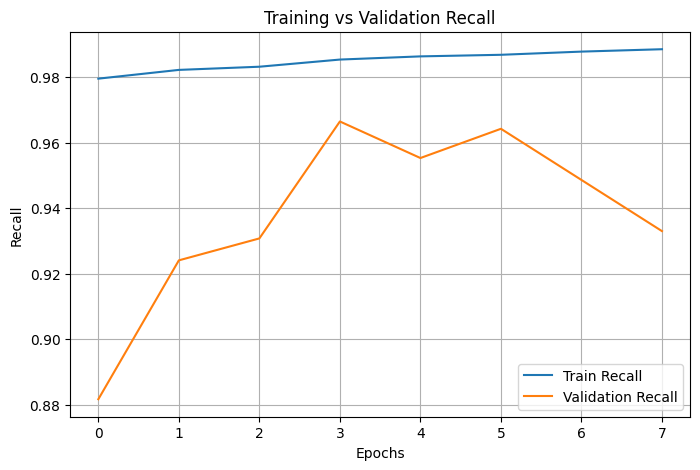

In [69]:
plt.figure(figsize=(8,5))
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall')
plt.legend()
plt.grid(True)
plt.show()


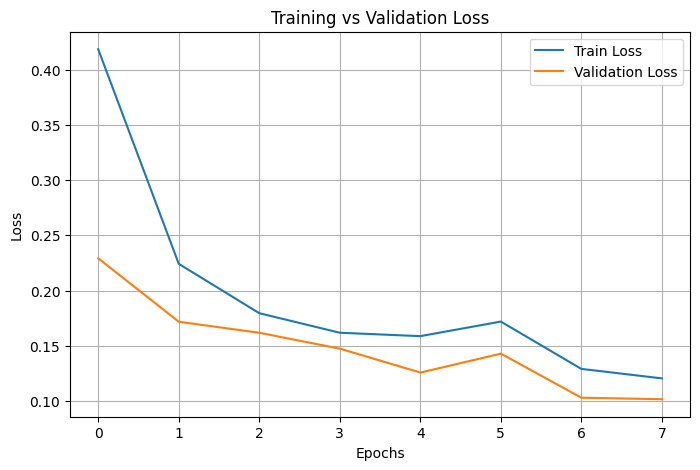

In [70]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


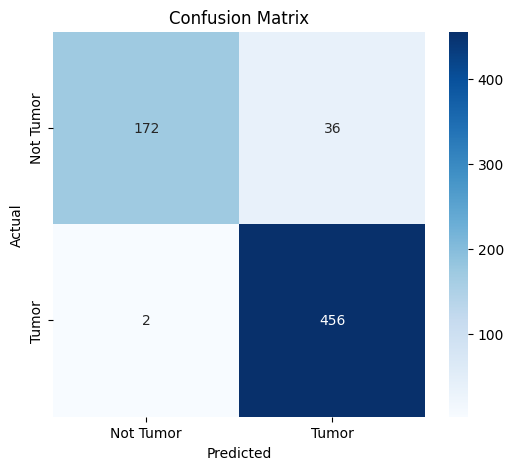

In [71]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Tumor', 'Tumor'],
            yticklabels=['Not Tumor', 'Tumor'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


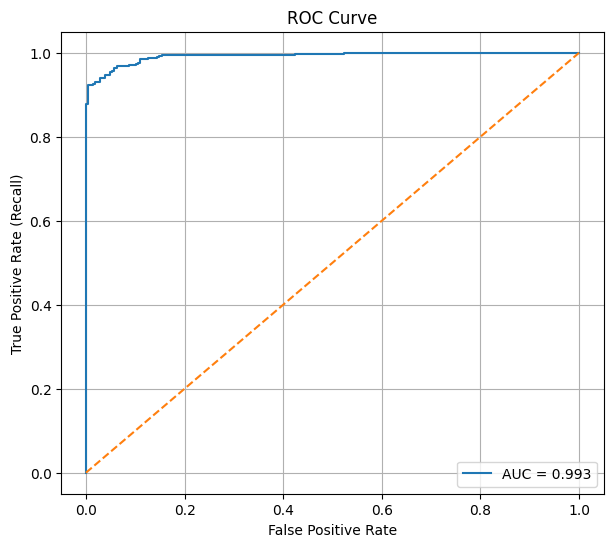

In [72]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
